<a href="https://colab.research.google.com/github/isamadafridi/potato_model/blob/main/potato_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Resizing, Rescaling, Conv2D, MaxPooling2D, Flatten,GlobalAveragePooling2D , Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Loading**

In [ ]:
# import kagglehub
# import shutil
# import os

# # Step 1: Download dataset (default location)
# path = kagglehub.dataset_download("arjuntejaswi/plant-village")

# # Step 2: Define your desired path
# target_path = '/content/drive/MyDrive/Datasets'

# # Step 3: Move dataset
# shutil.move(path, target_path)

# print("Dataset moved to:", target_path)

In [3]:
DATASET_PATH = '/content/drive/MyDrive/Datasets/1/PlantVillage'

In [4]:
from PIL import Image

img = Image.open("/content/drive/MyDrive/Datasets/1/PlantVillage/Potato___healthy/00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864.JPG")
print(img.size)   # (width, height)

(256, 256)


In [5]:
# STEP 1: Load Dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=[
        "Potato___Early_blight",
        "Potato___Late_blight",
        "Potato___healthy"
    ],
    shuffle = True,
    image_size=(256, 256),
    batch_size=32
)

Found 2152 files belonging to 3 classes.


In [6]:
CLASS_NAMES = dataset.class_names
CLASS_NAMES

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
print(f"Size without batch : {len(dataset)}")
print(f"Size with batch : {len(dataset)*32}")

Size without batch : 68
Size with batch : 2176


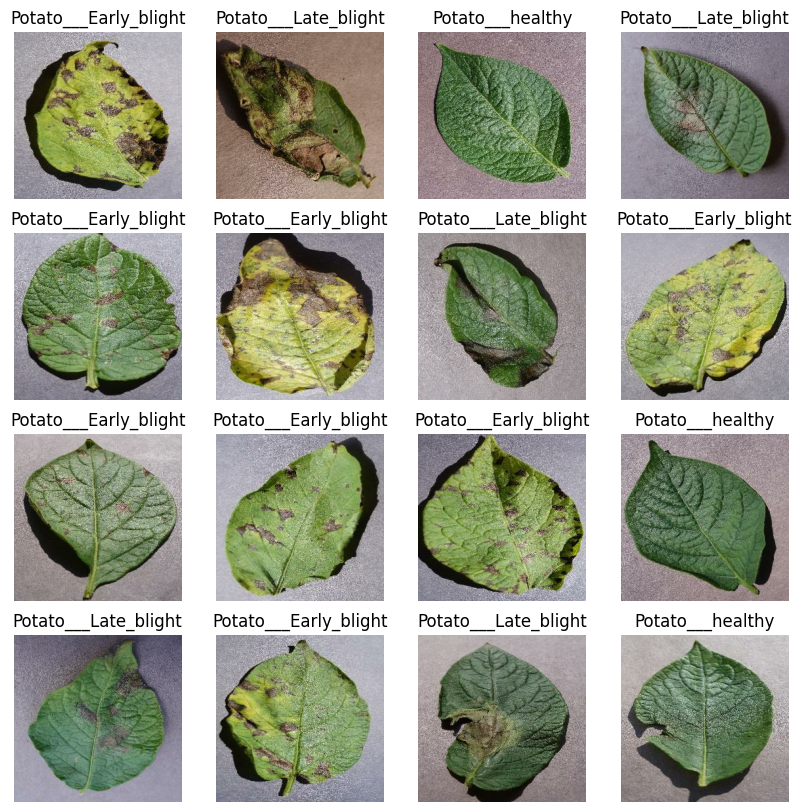

In [8]:
plt.figure(figsize=(10,10))
for image, label in dataset.take(1):
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(dataset.class_names[label[i].numpy()])
    plt.axis('off')

In [9]:
#  STEP 2: Split Dataset
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

  ds_size = len(ds)
  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=12)

  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)


  return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [10]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


# **Data pre-processing**

In [14]:
# resize_rescale_layers = tf.keras.Sequential([
#     Resizing(256, 256),
#     Rescaling(1./255)
# ])
# it cover procesiing unit

In [15]:
# STEP 3: Define Augmentation (CPU pipeline, training only)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

In [18]:
#  STEP 4: Apply Preprocessing
# TRAIN — preprocess + augment
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x), training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE   # 🔥 runs in parallel on CPU
)

In [19]:
# VAL — only preprocess
val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [20]:
# TEST — only preprocess
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [21]:
# STEP 5: Performance Optimization
# ============================================================
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# **Model Selection**

# Pretrained Model

In [22]:
# Step 1: Load the base model (no top = no final classification layer)
model_mobileNet2 = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,       # Remove ImageNet classifier
    weights='imagenet'       # Use pretrained weights
)

# Step 2: Freeze it first (don't train pretrained weights yet)
model_mobileNet2.trainable = False

# Step 3: Add your own classifier on top
model_mobileNet2 = tf.keras.Sequential([
    Input(shape=(256, 256, 3)),

    model_mobileNet2,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')   # Your 3 potato classes
])
model_mobileNet2.summary()

/tmp/ipykernel_7660/3631328200.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model_mobileNet2 = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Model Saving**

In [ ]:
import os
import re

base_path = '/content/drive/MyDrive/Best_Model'
model_name = "potato_model_mobileNetV2"

files = os.listdir(base_path)

versions = []

for f in files:
    if f.startswith(model_name) and f.endswith(".keras"):
        match = re.search(r'_v(\d+)', f)
        if match:
            versions.append(int(match.group(1)))

# next version
i = max(versions) + 1 if versions else 0

filepath = f"{base_path}/{model_name}_v{i}.keras"

print(filepath)

/content/drive/MyDrive/Best_Model/potato_model_mobileNetV2_v1.keras


# **Model Compailation**

In [ ]:
model = model_mobileNet2

In [ ]:
callback = [
    tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    # min_delta=0,
    patience=3,
    # verbose=0,
    mode='auto',
    # baseline=None,
    restore_best_weights=True,
    # start_from_epoch=0
),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    mode='auto',
),
    tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
)

]

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    batch_size = 32,
    verbose = 1,
    epochs = 50,
    callbacks = callback
)

Epoch 1/50


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))

# Plot training & validation accuracy values
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
plt.figure(figsize=(6, 4))

# Plot training & validation accuracy values
# plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Loss', 'val_loss'], loc='upper left')

plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()